In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/prince7489/online-vs-offline-learning-efficiency-dataset/online_vs_offline_learning_dataset.csv


Dataset Link :- https://www.kaggle.com/datasets/prince7489/online-vs-offline-learning-efficiency-dataset

In [2]:
data = pd.read_csv("/kaggle/input/datasets/prince7489/online-vs-offline-learning-efficiency-dataset/online_vs_offline_learning_dataset.csv")

# 1. Understanding Data

In [3]:
df = pd.DataFrame(data)
df.head()

,Learning_Mode,Subject,Study_Hours,Retention_Score,Focus_Level,Exam_Score
0,Offline,English,7.7,51,96,70
1,Offline,English,6.2,90,82,81
2,Online,English,1.2,75,66,71
3,Online,Math,6.5,80,64,77
4,Online,English,5.5,95,58,78


In [4]:
df.shape

(1000, 6)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

Learning_Mode      0
Subject            0
Study_Hours        0
Retention_Score    0
Focus_Level        0
Exam_Score         0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Learning_Mode    1000 non-null   object 
 1   Subject          1000 non-null   object 
 2   Study_Hours      1000 non-null   float64
 3   Retention_Score  1000 non-null   int64  
 4   Focus_Level      1000 non-null   int64  
 5   Exam_Score       1000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 47.0+ KB


In [8]:
df.describe()

,Study_Hours,Retention_Score,Focus_Level,Exam_Score
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,4.563500,72.69100,71.261000,71.675000
std,2.000115,17.69827,18.053166,12.984297
min,1.000000,40.00000,40.000000,39.000000
25%,2.800000,58.00000,56.000000,62.000000
50%,4.700000,72.00000,72.000000,72.000000
75%,6.300000,88.00000,87.000000,81.000000
max,8.000000,100.00000,100.000000,100.000000


Spelling Check

In [9]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(col)
    print("Total Number of Unique values : ",df[col].nunique())
    print("Total Unique values : ",df[col].unique())

Learning_Mode
Total Number of Unique values :  2
Total Unique values :  ['Offline' 'Online']
Subject
Total Number of Unique values :  5
Total Unique values :  ['English' 'Math' 'Science' 'Programming' 'History']


# 2. Data Cleaning

## 2.1 Renaming Column

In [10]:
df = df.rename(columns={"Learning_Mode": "is_online"})

## 2.2 Converting `Learning_Mode` into int

In [11]:
df["is_online"] = df["is_online"].map({
    "Offline": 0,
    "Online": 1
}).astype(int)

# 3. EDA

In [12]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.drop('is_online')
# Binary columns (better visualized with count plots)
extra_num_cols = ['is_online']
cat_cols = df.select_dtypes(include='object').columns

In [13]:
print(f"Total num_cols are : ",len(num_cols))
print(f"Total cat_cols are : ",len(cat_cols))

Total num_cols are :  4
Total cat_cols are :  1


## 3.1 Univariate Analysis

### 3.1.1 Numerical Columns

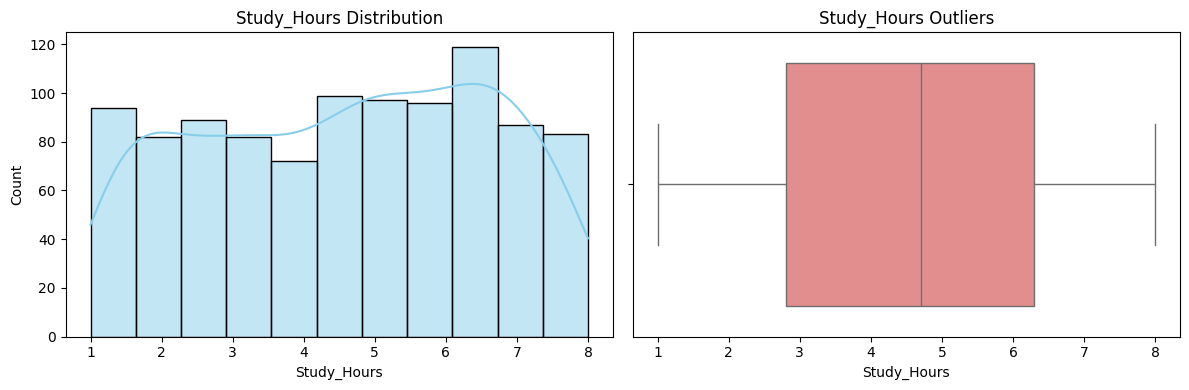

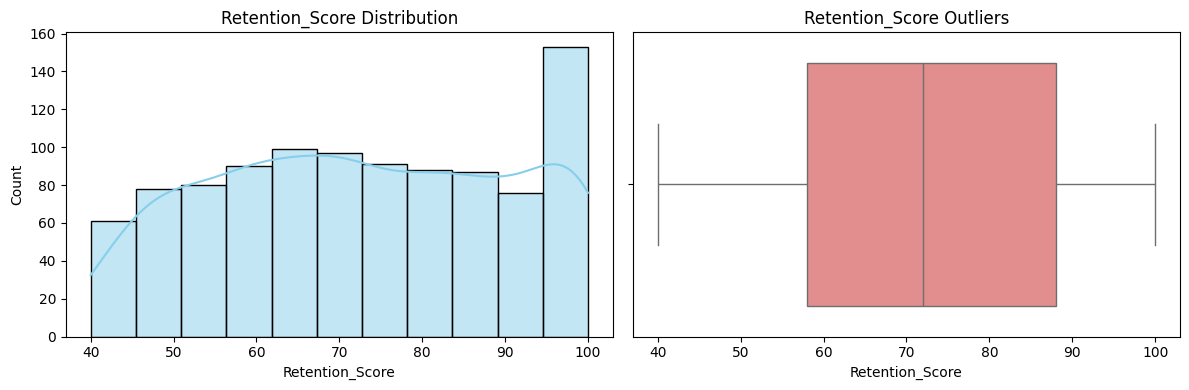

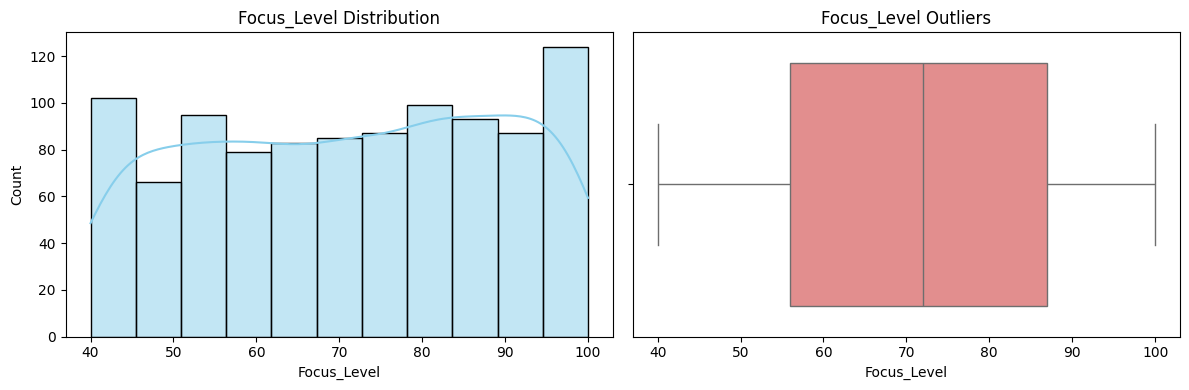

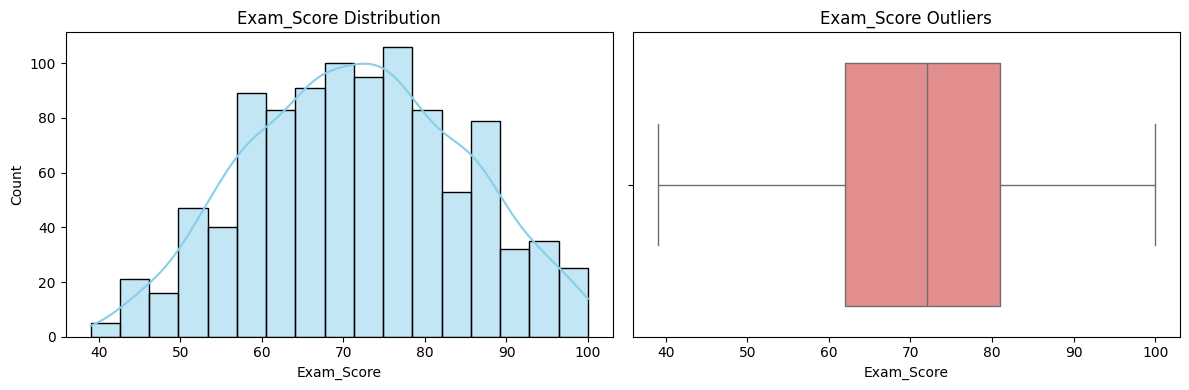

In [14]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

### 3.1.2 Categorical Columns (Count plots)

In [15]:
import math

def count_plot(cols):
    n = len(cols)
    rows = math.ceil(n / 2)

    plt.figure(figsize=(14, 5 * rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(rows, 2, i)

        sns.countplot(
            data=df,
            x=col,
            order=df[col].value_counts().index,
            legend=True
        )

        plt.title(f'{col} Frequency')
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

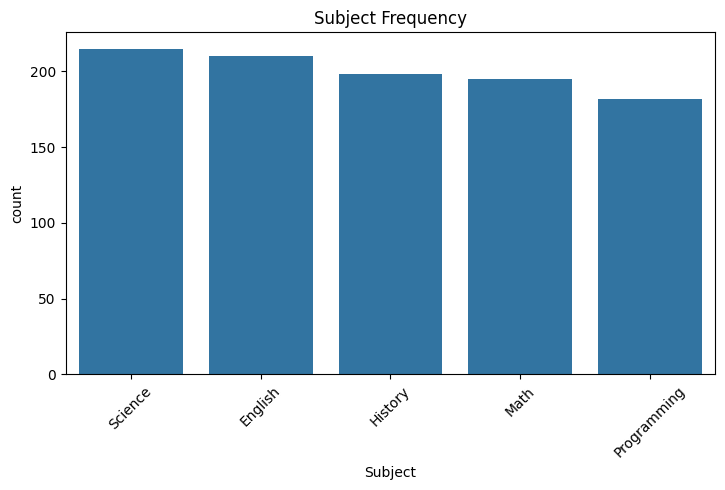

In [16]:
count_plot(cat_cols)

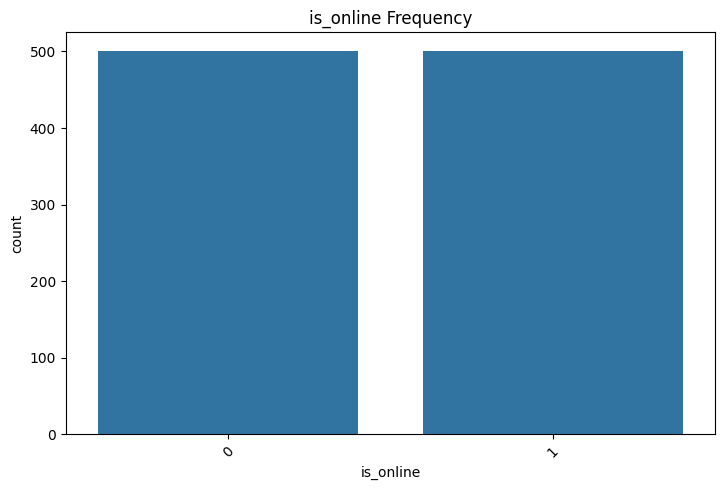

In [17]:
count_plot(extra_num_cols)

`is_online` contains almost equivalent values

## 3.2 Bivariate Analysis

### 3.2.1 Numerical vs Numerical

**Correlation Heatmap**

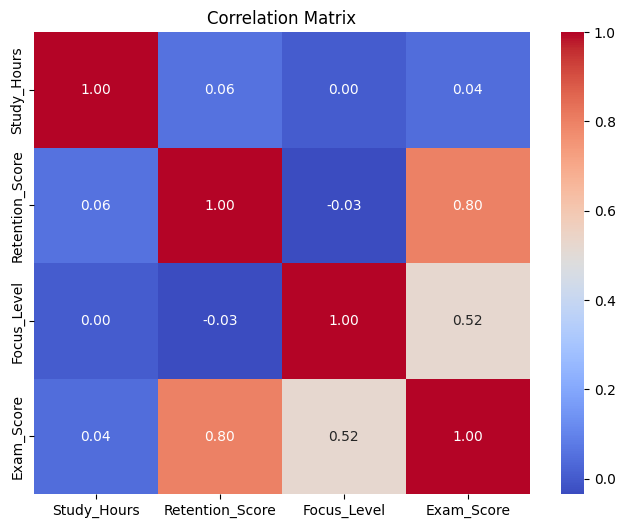

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

**Pairplot**

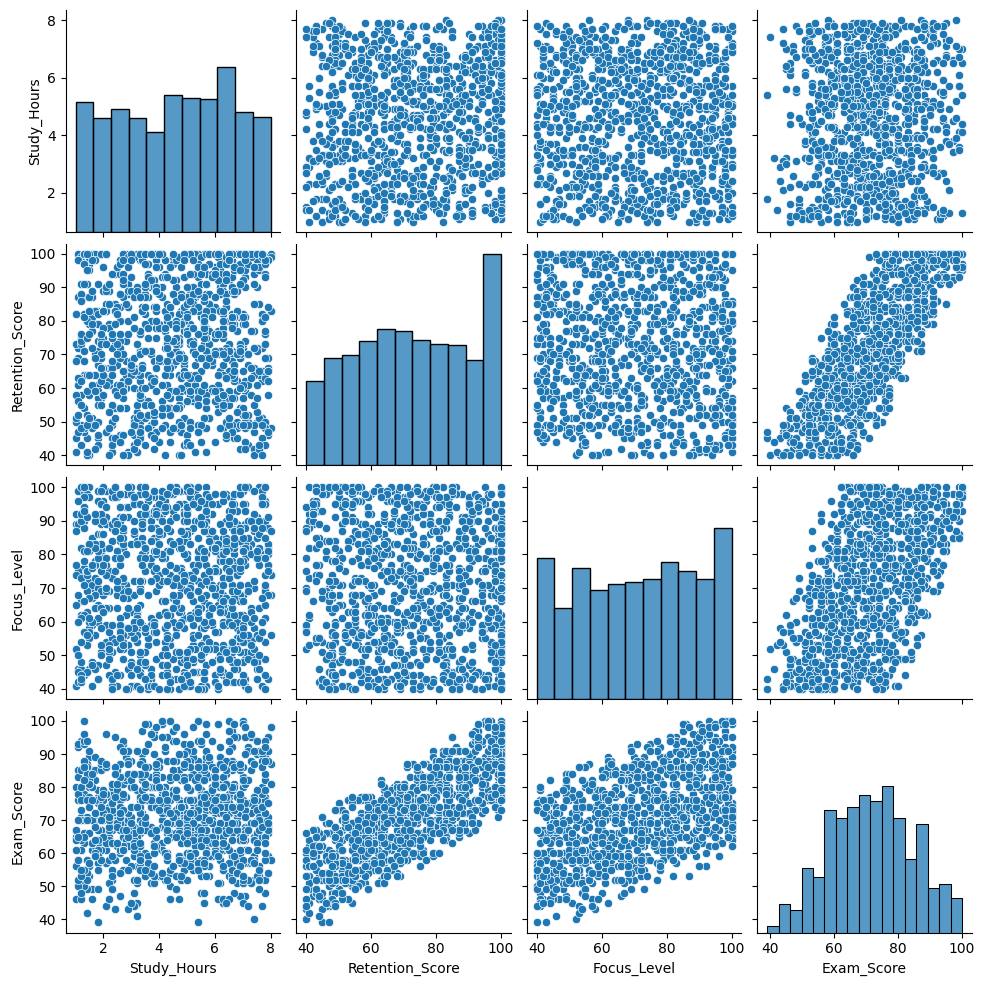

In [19]:
sns.pairplot(df[num_cols])
plt.show()

### 3.2.2 Numerical vs Categorical

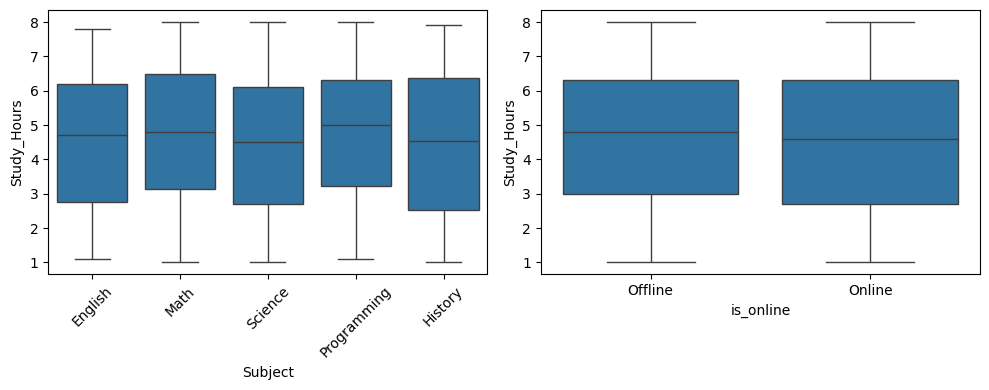

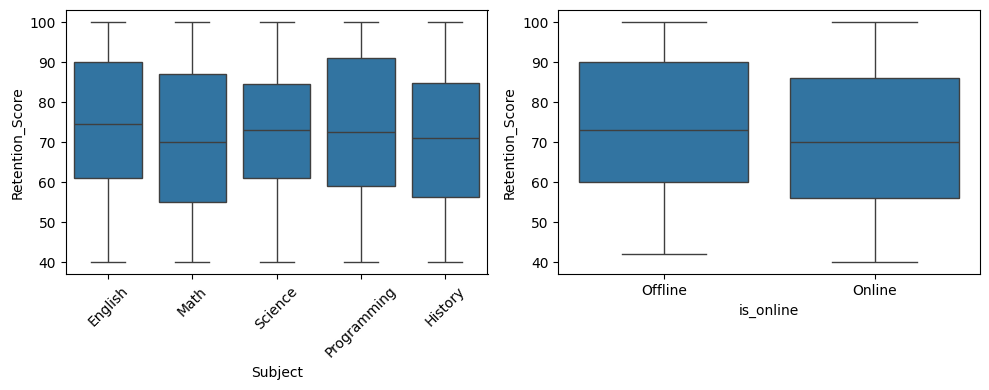

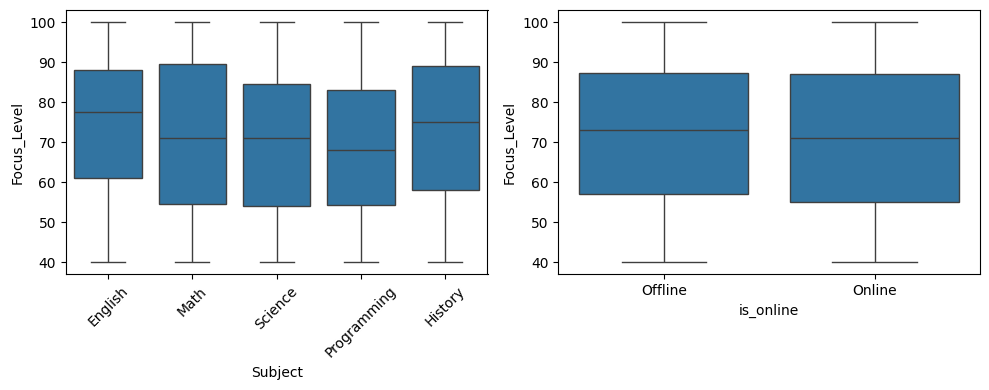

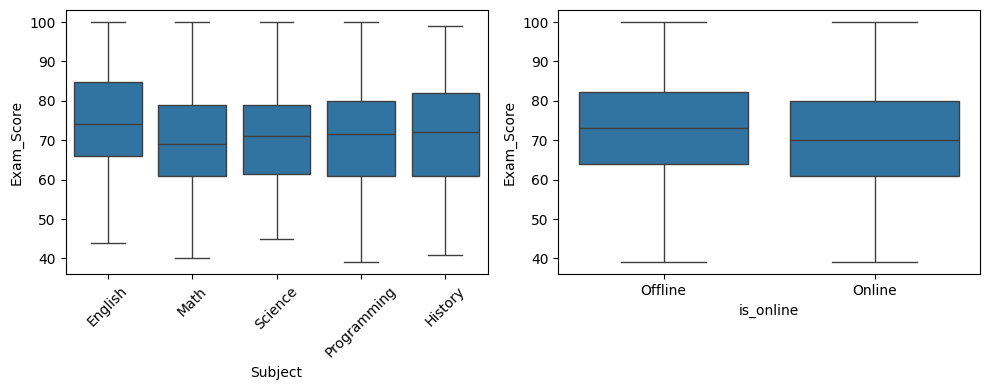

In [20]:
num_cols = ['Study_Hours', 'Retention_Score', 'Focus_Level', 'Exam_Score']

for col in num_cols:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.boxplot(data=df, x='Subject', y=col)
    plt.xticks(rotation=45)

    plt.subplot(1,2,2)
    sns.boxplot(data=df, x='is_online', y=col)
    plt.xticks([0,1], ['Offline','Online'])

    plt.tight_layout()
    plt.show()

## 3.3 Multivariate Analysis

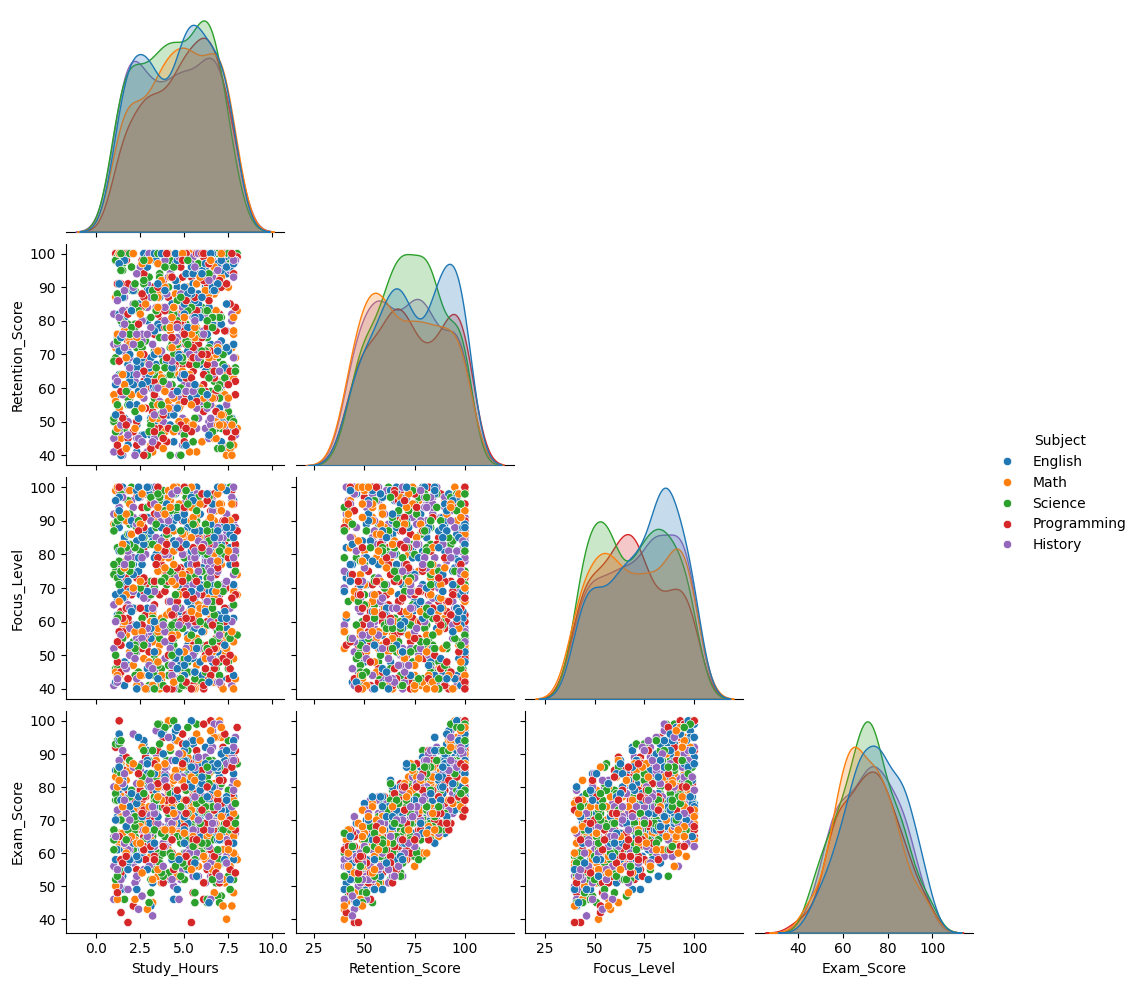

In [21]:
# Pairplot with categorical hue
sns.pairplot(
    df,
    vars=['Study_Hours', 'Retention_Score', 'Focus_Level', 'Exam_Score'],
    hue='Subject',
    corner=True
)
plt.show()

**Bar Plot**

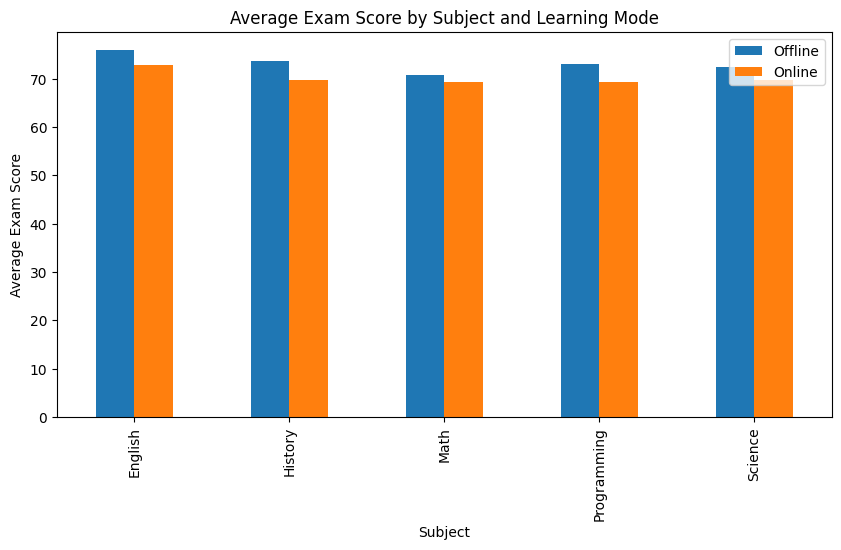

In [22]:
pivot = pd.pivot_table(
    df,
    values='Exam_Score',
    index='Subject',
    columns='is_online',
    aggfunc='mean'
)

pivot.columns = ['Offline', 'Online']

pivot.plot(
    kind='bar',
    figsize=(10,5)
)

plt.ylabel("Average Exam Score")
plt.title("Average Exam Score by Subject and Learning Mode")
plt.show()

**Bubble Plot**

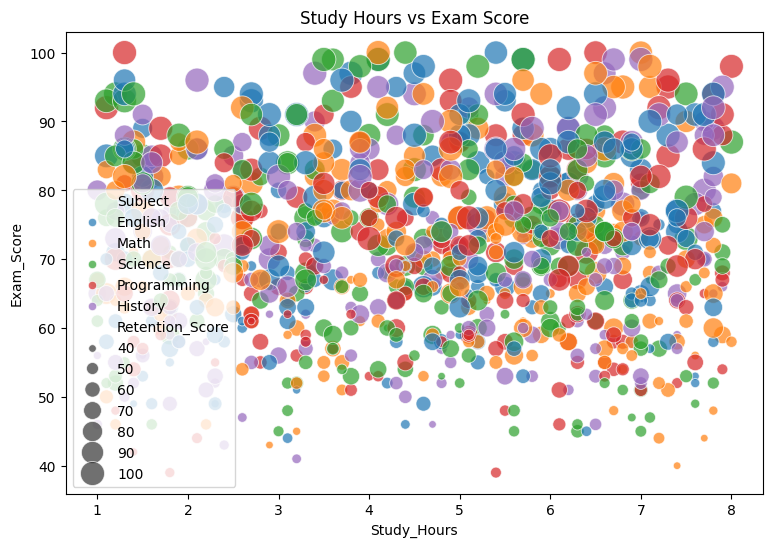

In [23]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Study_Hours',
    y='Exam_Score',
    size='Retention_Score',
    hue='Subject',
    alpha=0.7,
    sizes=(30,300)
)

plt.title("Study Hours vs Exam Score")
plt.show()

Text(0.5, 1.0, 'Exam Score Distribution')

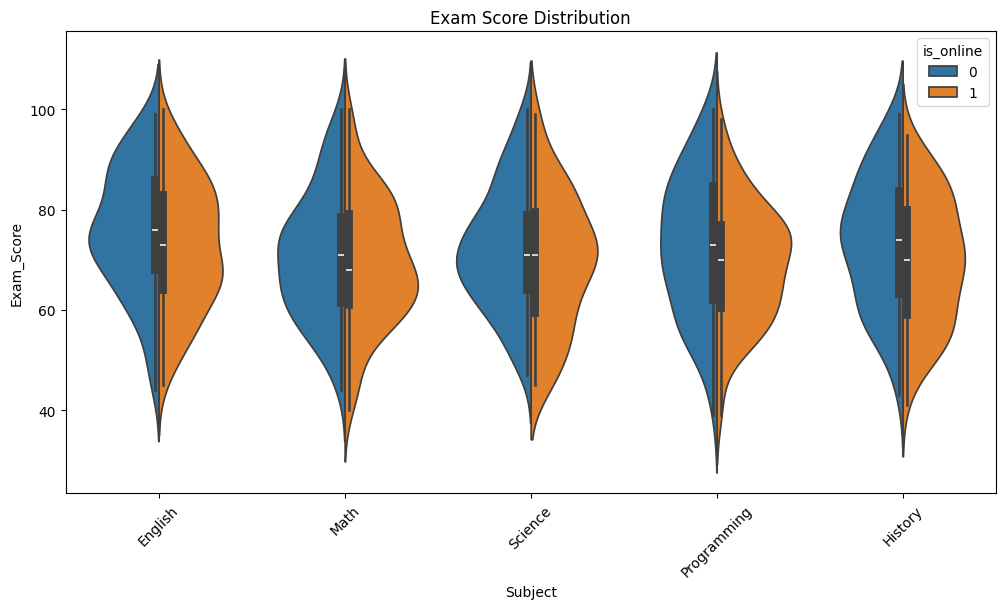

In [24]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='Subject',
    y='Exam_Score',
    hue='is_online',
    split=True
)

plt.xticks(rotation=45)
plt.title("Exam Score Distribution")


# 4. Feature transformation

In [25]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [26]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [27]:
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 5. ML and Hyperparameter Tuning

In [29]:
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score

# Tree-Based Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Boosting Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [30]:
models = {

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    # ============================
    # Boosting Models
    # ============================
    "XGBoost": XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        tree_method='hist'
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        force_col_wise=True,
        verbose=-1
    )
}

In [31]:
param_grids = {

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, 15, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 5, 10],
        "criterion": ["squared_error", "friedman_mse"]
    },

    "Random Forest": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    },

    # ============================
    # Boosting Models 
    # ============================
    "XGBoost": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 4, 5, 6, 7],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.7, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
        "gamma": [0, 0.1, 0.2]
    },

    "LightGBM": {
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "num_leaves": [15, 31, 50, 70],
        "max_depth": [-1, 3, 5, 7, 10],
        "min_child_samples": [5, 10, 20, 30],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0]
    }
}

In [32]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [33]:
best_model = None
best_score = -float("inf")
best_model_name = ""

results = {}

for name, model in models.items():
    
    print(f"\nRunning RandomizedSearchCV for {name}...")
    
    random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grids[name],
    cv=kf,
    scoring='r2',
    n_jobs=1,
    n_iter=20 if model == "LightGBM" else 50,
    random_state=42
    )

    random_search.fit(X_train, y_train)

    results[name] = {
        "Best Params": random_search.best_params_,
        "Best CV Score (R2)": random_search.best_score_
    }

    print(name)
    print("Best Params:", random_search.best_params_)
    print("Best CV Score (R2):", random_search.best_score_)

    # STORE ONLY BEST MODEL
    if random_search.best_score_ > best_score:
        best_score = random_search.best_score_
        best_model = random_search.best_estimator_
        best_model_name = name


Running RandomizedSearchCV for Decision Tree...
Decision Tree
Best Params: {'min_samples_split': 5, 'min_samples_leaf': 10, 'max_depth': 7, 'criterion': 'squared_error'}
Best CV Score (R2): 0.9084521720049239

Running RandomizedSearchCV for Random Forest...
Random Forest
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV Score (R2): 0.914825995418352

Running RandomizedSearchCV for XGBoost...
XGBoost
Best Params: {'subsample': 0.6, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV Score (R2): 0.9307004094123841

Running RandomizedSearchCV for LightGBM...
LightGBM
Best Params: {'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 300, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV Score (R2): 0.9313029479145124


In [34]:
# DataFrame of results to make it more readable
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Best CV Score (R2)", ascending=False)

,Best Params,Best CV Score (R2)
LightGBM,"{'subsample': 1.0, 'num_leaves': 50, 'n_estima...",0.931303
XGBoost,"{'subsample': 0.6, 'n_estimators': 100, 'max_d...",0.9307
Random Forest,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.914826
Decision Tree,"{'min_samples_split': 5, 'min_samples_leaf': 1...",0.908452


In [35]:
print("Best Model:", best_model_name)
print("Best CV Score (R2):", best_score)

Best Model: LightGBM
Best CV Score (R2): 0.9313029479145124


In [36]:
y_pred = best_model.predict(X_test)

In [37]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.6365671472982632
RMSE: 3.1385937439962004
R2 Score: 0.9409229205491815
